In [29]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
# Set the root path as if it's being ran from the project root
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.append(project_root)

In [31]:
import pygad
import numpy as np
import torch
import os
from ga.components.ga import on_crossover_func, on_generation_func, calculate_dynamic_probs
from ga.components.fitness import constrained_fitness_func
from ga.components.mutation import paper_style_mutation, random_float_mutation, custom_mutation
from ga.components.crossover import pixel_cleaning_operation
from ga.components.model import load_model, evaluate_without_perturbation, evaluate_with_perturbation
from ga.utils import get_dataloader, visualize_images_batch,visualize_image, visualize_perturbation, compute_pixel_statistics, load_config

In [32]:
# Use GPU instead of CPU

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# Parameters

In [33]:
config = load_config()

In [34]:
# num_generations =num_generations=config["ga"]["num_generations"]
# num_parents_mating=config["ga"]["num_parents_mating"]
# sol_per_pop=config["ga"]["sol_per_pop"]
# init_range_low=config["ga"]["init_range_low"]
# init_range_high=config["ga"]["init_range_high"]
# mutation_percent_genes=config["ga"]["mutation_percent_genes"]

# model_type = config["model"]["model_type"]
# batch_size = config["model"]["batch_size"]

# visualize = config["visualization"]["visualize"]
# visualize_every = config["visualization"]["visualize_every"]


# Model

In [35]:
model = load_model(config["model"]["model_type"], device=device)

Loading model: googlenet
Using device: mps


# Loading

In [36]:
# Load
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
image_dir = os.path.join(project_root, "nn/data/imagenet/val")
dataloader = get_dataloader(config["model"]["batch_size"], image_dir)


## Compute statistics - no need to run now

In [37]:
# Compute the pixel mean and standard deviation for each pixel across the entire dataset - for constrained fitness func

# pixel_mean, pixel_std = compute_pixel_statistics(dataloader)

# Roughly 0.04, 1.18, since we already normalize the dataset

In [38]:
# First batch
input_batch, labels = next(iter(dataloader))
input_batch, labels = input_batch.to(device), labels.to(device)

# Collect top perturbations from each generation
top_perturbations = []

# GA Config


Generation 1 completed with fitness: [-3.81851034 -3.79956045 -3.86654958 -3.82195882 -3.86227254 -3.82119893
 -3.83630514 -3.84412221 -3.83918447 -3.84299917 -3.79605398 -3.85967855
 -3.81821126 -3.88394918 -3.83018331 -3.85978841 -3.83447408 -3.79010152
 -3.81381368 -3.83646688 -3.82530813 -3.86641073 -3.82059926 -3.82179555
 -3.83967275 -3.79794301 -3.8056014  -3.80775747 -3.79138174 -3.8118575
 -3.8387206  -3.84661092 -3.86881551 -3.76509084 -3.83922109 -3.8013915
 -3.8059554  -3.80745992 -3.85755147 -3.78031148 -3.81146535 -3.8435317
 -3.77946767 -3.84947042 -3.85740041 -3.78963918 -3.82856283 -3.83164815
 -3.85628194 -3.82651205]
Best Fitness = -3.765090841509706

Best solution snippet: [ 0.31234261 -0.19011275 -0.14755797  0.37441889 -0.22878038  0.43758209
 -0.43898434  0.45907219 -0.18363972  0.        ]
Best solution zeros count: 14998
Best perturbation magnitude: 106.01445770263672
New crossover & mutation probabilities: 0.8921875, 0.59375

Generation 2 completed with fitne

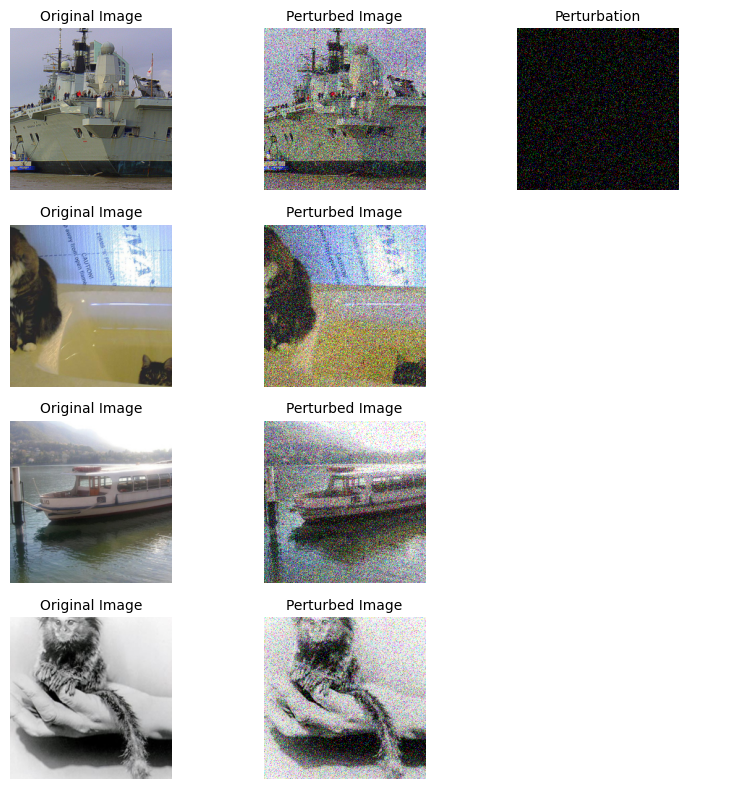

New crossover & mutation probabilities: 0.8375, 0.5499999999999999

Generation 9 completed with fitness: [0.578125 0.609375 0.546875 0.546875 0.578125 0.609375 0.578125 0.59375
 0.625    0.59375  0.578125 0.578125 0.59375  0.578125 0.578125 0.578125
 0.5625   0.578125 0.59375  0.578125 0.59375  0.546875 0.609375 0.5625
 0.578125 0.59375  0.578125 0.5625   0.59375  0.5625   0.578125 0.546875
 0.59375  0.5625   0.578125 0.5625   0.609375 0.59375  0.546875 0.578125
 0.609375 0.59375  0.609375 0.578125 0.578125 0.578125 0.59375  0.578125
 0.59375  0.625   ]
Best Fitness = 0.625

Best solution snippet: [ 0.          0.          0.31789337  0.          0.          0.
 -0.43898434  0.          0.          0.        ]
Best solution zeros count: 91176
Best perturbation magnitude: 69.90322875976562
New crossover & mutation probabilities: 0.8296875, 0.54375

Generation 10 completed with fitness: [0.59375  0.59375  0.59375  0.546875 0.5625   0.578125 0.578125 0.609375
 0.5625   0.5625   0.578125 0

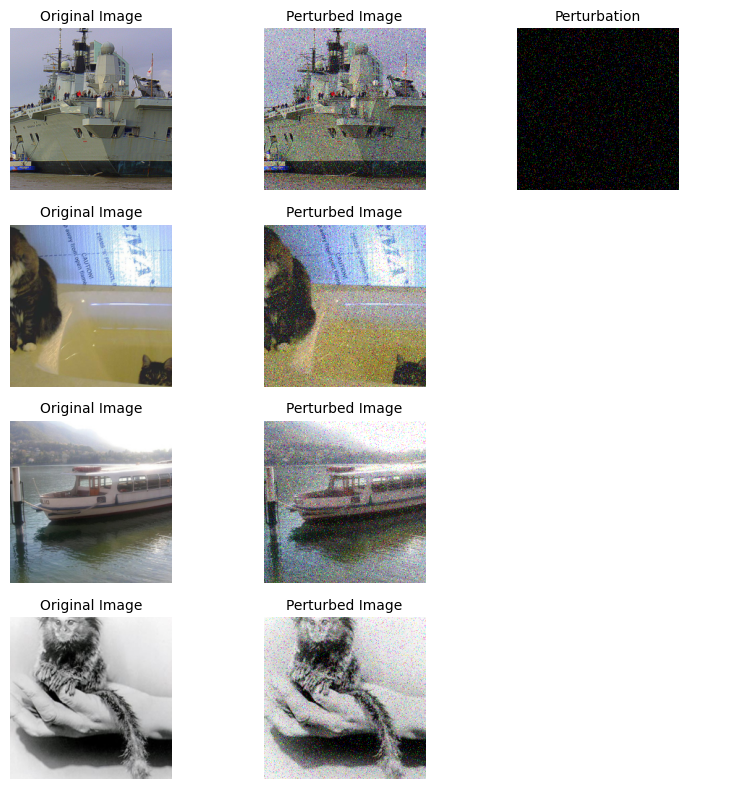

New crossover & mutation probabilities: 0.775, 0.5

Generation 17 completed with fitness: [0.5625   0.546875 0.546875 0.578125 0.578125 0.5625   0.5625   0.53125
 0.53125  0.546875 0.5625   0.546875 0.5625   0.5625   0.5      0.5625
 0.546875 0.546875 0.546875 0.578125 0.53125  0.546875 0.546875 0.5625
 0.546875 0.5625   0.546875 0.578125 0.546875 0.53125  0.5625   0.5625
 0.5625   0.5625   0.546875 0.546875 0.546875 0.53125  0.5625   0.546875
 0.5625   0.5625   0.5625   0.578125 0.546875 0.5625   0.578125 0.5625
 0.546875 0.5625  ]
Best Fitness = 0.578125

Best solution snippet: [0.         0.         0.31789337 0.         0.         0.
 0.         0.         0.         0.        ]
Best solution zeros count: 122969
Best perturbation magnitude: 47.660675048828125
New crossover & mutation probabilities: 0.7671875, 0.49374999999999997

Generation 18 completed with fitness: [0.546875 0.53125  0.546875 0.546875 0.546875 0.546875 0.53125  0.53125
 0.5625   0.546875 0.53125  0.546875 0.5625 

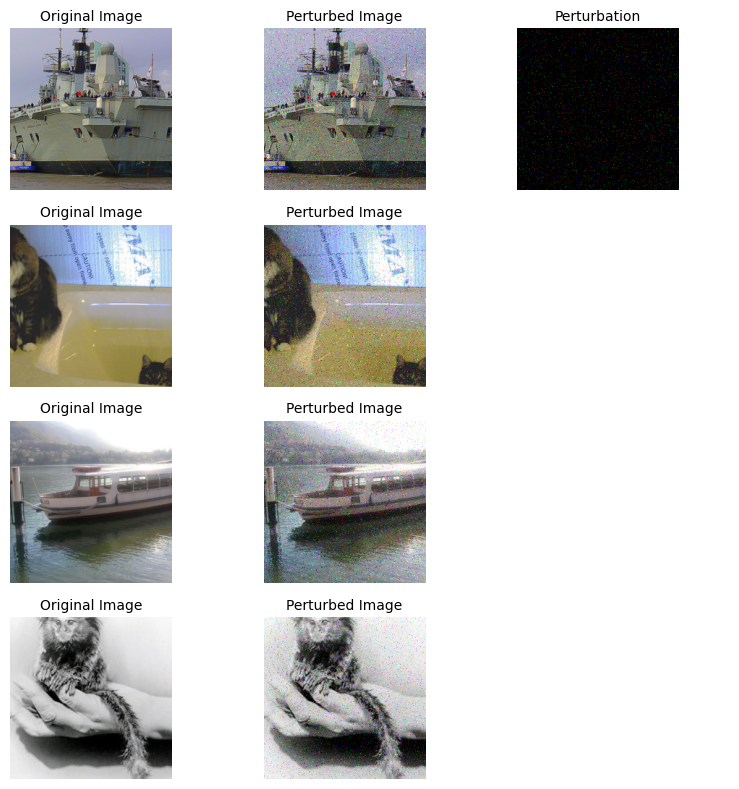

New crossover & mutation probabilities: 0.7125, 0.44999999999999996

Generation 25 completed with fitness: [0.578125 0.53125  0.53125  0.5      0.53125  0.5625   0.578125 0.546875
 0.578125 0.53125  0.5625   0.53125  0.546875 0.53125  0.546875 0.546875
 0.515625 0.515625 0.546875 0.53125  0.546875 0.53125  0.546875 0.5625
 0.5625   0.5625   0.53125  0.5625   0.5625   0.515625 0.5625   0.5625
 0.53125  0.5625   0.515625 0.515625 0.53125  0.515625 0.546875 0.5625
 0.5625   0.546875 0.546875 0.53125  0.5625   0.5625   0.53125  0.515625
 0.546875 0.5625  ]
Best Fitness = 0.578125

Best solution snippet: [0.         0.         0.         0.21209126 0.         0.
 0.         0.         0.         0.        ]
Best solution zeros count: 136424
Best perturbation magnitude: 34.08598327636719
New crossover & mutation probabilities: 0.7046875, 0.44375

Generation 26 completed with fitness: [0.578125 0.515625 0.5625   0.546875 0.546875 0.5625   0.53125  0.53125
 0.53125  0.5625   0.546875 0.515625 

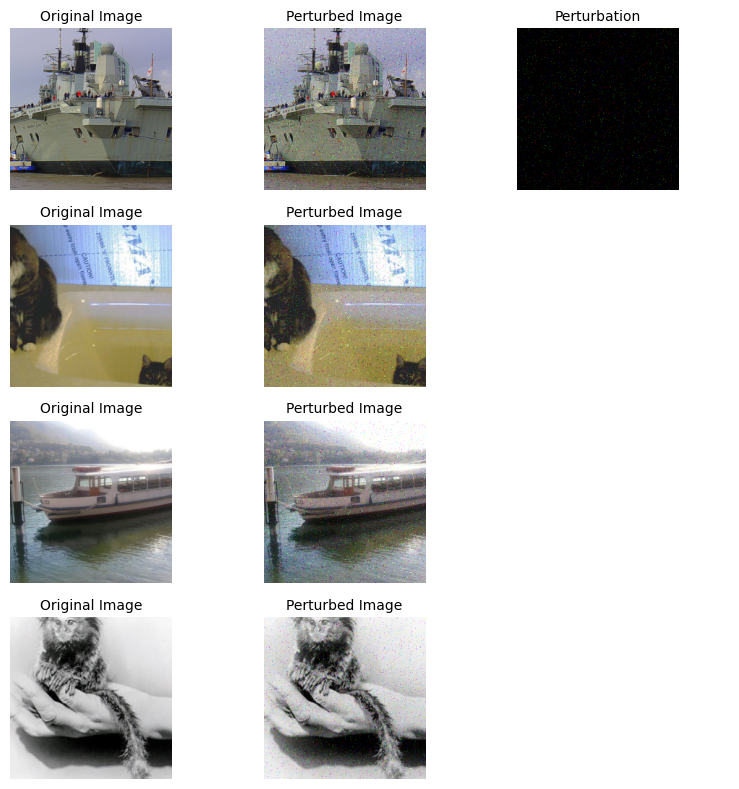

New crossover & mutation probabilities: 0.65, 0.4

Generation 33 completed with fitness: [0.53125  0.53125  0.53125  0.53125  0.546875 0.53125  0.546875 0.546875
 0.546875 0.53125  0.546875 0.546875 0.5625   0.546875 0.53125  0.53125
 0.546875 0.53125  0.53125  0.5625   0.53125  0.5625   0.546875 0.515625
 0.515625 0.484375 0.546875 0.546875 0.53125  0.53125  0.53125  0.546875
 0.5625   0.546875 0.546875 0.546875 0.546875 0.546875 0.5625   0.546875
 0.546875 0.546875 0.546875 0.5625   0.546875 0.546875 0.546875 0.53125
 0.546875 0.5625  ]
Best Fitness = 0.5625

Best solution snippet: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Best solution zeros count: 142138
Best perturbation magnitude: 26.477819442749023
New crossover & mutation probabilities: 0.6421875, 0.39375

Generation 34 completed with fitness: [0.546875 0.546875 0.53125  0.546875 0.53125  0.515625 0.5625   0.53125
 0.53125  0.53125  0.5      0.515625 0.515625 0.546875 0.5625   0.5625
 0.53125  0.53125  0.515625 0.546875 0.546875 0.515625

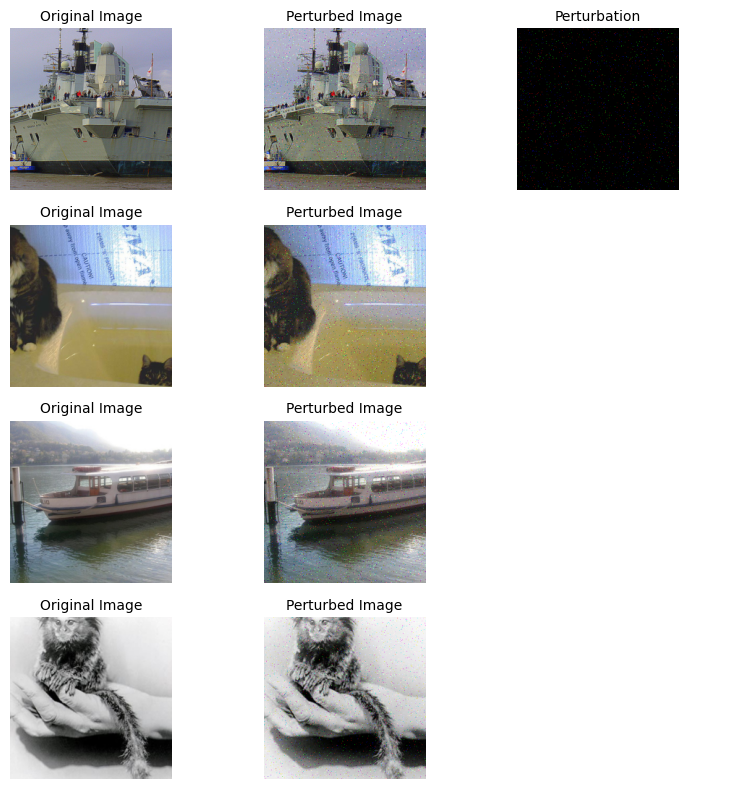

New crossover & mutation probabilities: 0.5875, 0.35

Generation 41 completed with fitness: [0.546875 0.53125  0.515625 0.546875 0.546875 0.53125  0.53125  0.53125
 0.53125  0.53125  0.53125  0.515625 0.546875 0.546875 0.53125  0.546875
 0.5625   0.546875 0.53125  0.53125  0.53125  0.5625   0.515625 0.546875
 0.546875 0.5625   0.53125  0.53125  0.515625 0.546875 0.5625   0.5
 0.53125  0.5625   0.515625 0.546875 0.53125  0.546875 0.53125  0.5
 0.546875 0.546875 0.53125  0.578125 0.546875 0.546875 0.546875 0.515625
 0.515625 0.546875]
Best Fitness = 0.578125

Best solution snippet: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Best solution zeros count: 144544
Best perturbation magnitude: 22.480541229248047
New crossover & mutation probabilities: 0.5796875, 0.34375

Generation 42 completed with fitness: [0.5625   0.53125  0.5625   0.546875 0.546875 0.53125  0.5625   0.546875
 0.546875 0.546875 0.5625   0.5      0.546875 0.53125  0.53125  0.546875
 0.53125  0.5625   0.546875 0.53125  0.53125  0.5      

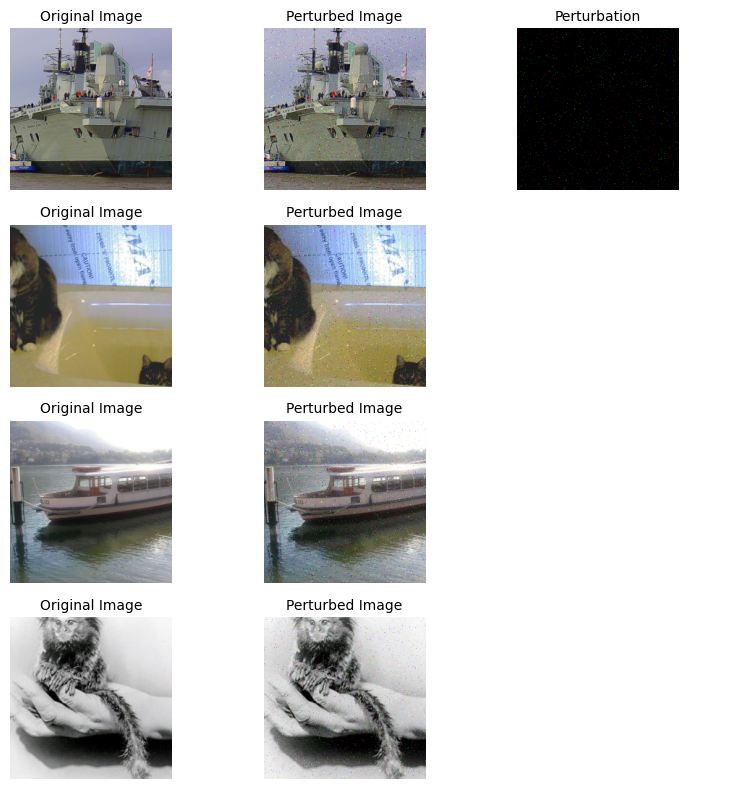

New crossover & mutation probabilities: 0.525, 0.3

Generation 49 completed with fitness: [0.5625   0.5625   0.5      0.546875 0.546875 0.53125  0.53125  0.546875
 0.53125  0.5625   0.546875 0.5625   0.5625   0.5625   0.53125  0.546875
 0.53125  0.546875 0.5625   0.546875 0.546875 0.53125  0.5625   0.546875
 0.515625 0.515625 0.546875 0.5625   0.5625   0.5625   0.53125  0.5625
 0.546875 0.546875 0.5625   0.515625 0.5625   0.53125  0.515625 0.5625
 0.53125  0.546875 0.53125  0.546875 0.546875 0.515625 0.53125  0.546875
 0.546875 0.53125 ]
Best Fitness = 0.5625

Best solution snippet: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Best solution zeros count: 145460
Best perturbation magnitude: 20.508127212524414
New crossover & mutation probabilities: 0.5171875, 0.29375

Generation 50 completed with fitness: [0.53125  0.5625   0.546875 0.53125  0.5625   0.546875 0.53125  0.53125
 0.515625 0.546875 0.53125  0.5625   0.53125  0.53125  0.5625   0.546875
 0.53125  0.546875 0.515625 0.53125  0.546875 0.54687

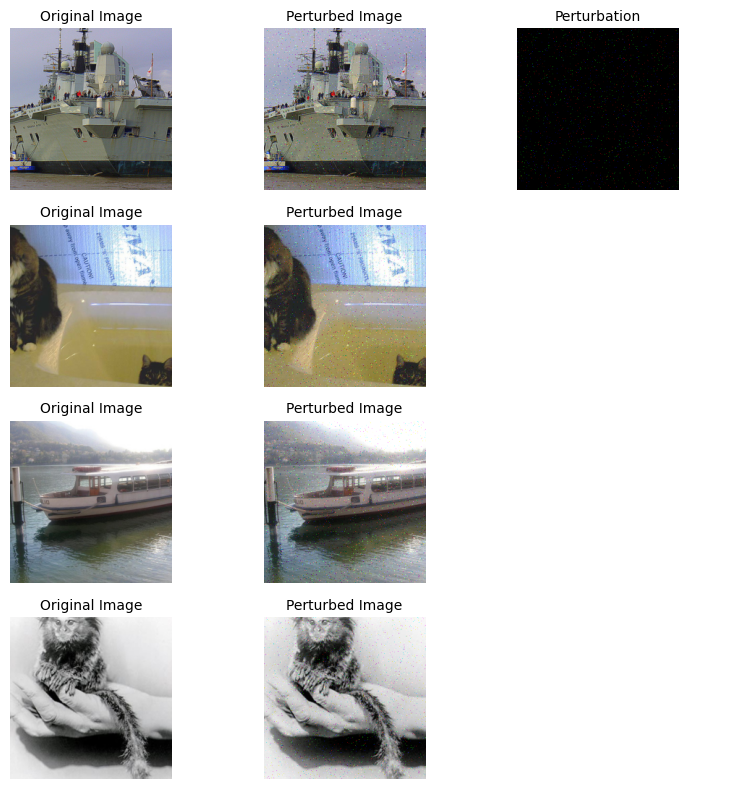

New crossover & mutation probabilities: 0.4625, 0.25

Generation 57 completed with fitness: [0.515625 0.546875 0.53125  0.515625 0.5625   0.546875 0.5625   0.53125
 0.5625   0.515625 0.546875 0.546875 0.546875 0.53125  0.546875 0.546875
 0.546875 0.53125  0.546875 0.5625   0.546875 0.546875 0.5625   0.5625
 0.546875 0.546875 0.546875 0.53125  0.5625   0.546875 0.5625   0.5625
 0.5625   0.5625   0.5625   0.546875 0.546875 0.53125  0.5625   0.5625
 0.53125  0.53125  0.53125  0.546875 0.53125  0.5625   0.5625   0.546875
 0.546875 0.5625  ]
Best Fitness = 0.5625

Best solution snippet: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Best solution zeros count: 146243
Best perturbation magnitude: 18.9495849609375
New crossover & mutation probabilities: 0.4546875, 0.24375000000000002

Generation 58 completed with fitness: [0.53125  0.53125  0.53125  0.546875 0.546875 0.546875 0.546875 0.5625
 0.546875 0.53125  0.5625   0.546875 0.53125  0.5625   0.546875 0.53125
 0.546875 0.53125  0.5625   0.546875 0.5625   

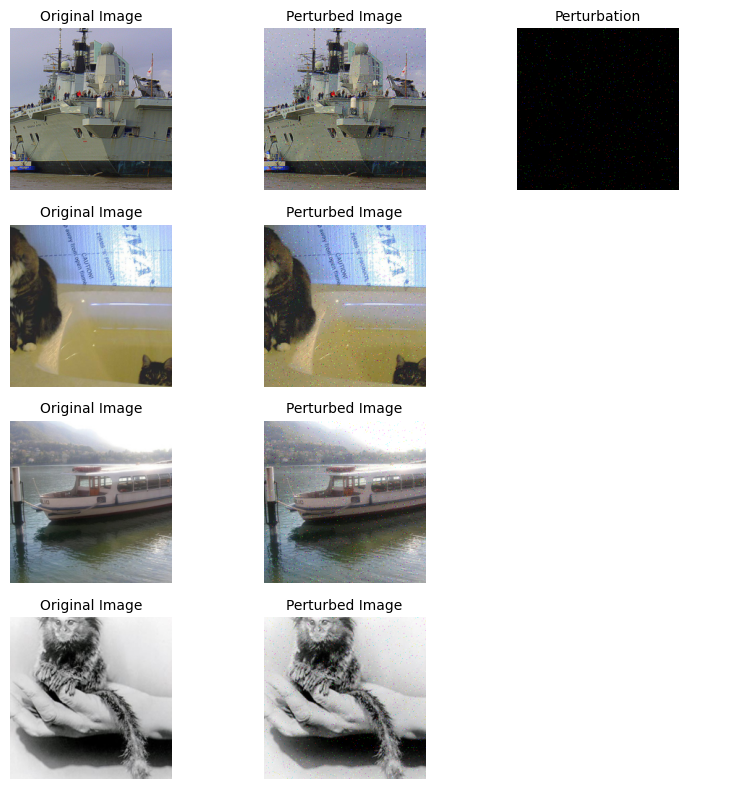

New crossover & mutation probabilities: 0.4, 0.2


In [51]:
config = load_config()

ga_instance = pygad.GA(
    num_generations=config["ga"]["num_generations"],
    num_parents_mating=config["ga"]["num_parents_mating"],
    sol_per_pop=config["ga"]["sol_per_pop"],
    num_genes=3*224*224,
    gene_type=float,
    init_range_low=config["ga"]["init_range_low"],
    init_range_high=config["ga"]["init_range_high"],
    parent_selection_type=config["ga"]["parent_selection_type"],
    keep_elitism=config["ga"]["keep_elitism"],
    keep_parents=config["ga"]["keep_parents"],
    crossover_type=config["crossover"]["crossover_type"],
    crossover_probability=config["crossover"]["p_crossover_init"],
    mutation_type=lambda ga_inst, offspring: paper_style_mutation(ga_inst, offspring, config["mutation"]["p_mutation_init"], config["mutation"]["p_flip"]),
    fitness_func=lambda ga_inst, solution, solution_idx: constrained_fitness_func(
        ga_inst, solution, solution_idx, model, input_batch, labels, config["fitness"]["epsilon_init"], config["fitness"]["epsilon_end"], config["fitness"]["penalty_factor"]
    ),
    on_generation=lambda ga_inst: on_generation_func(ga_inst, input_batch, top_perturbations, config),
    on_crossover=lambda ga_inst, offspring: on_crossover_func(ga_inst, offspring, config),
)

ga_instance.run()

In [46]:
input_batch.shape

torch.Size([64, 3, 224, 224])

In [52]:
# After the run
solution, solution_fitness, _ = ga_instance.best_solution()
print(f"Best solution fitness: {solution_fitness}") # Might be the penultimate best fitness??

Best solution fitness: 0.5625


# Calculating Universal Perturbation

torch.Size([3, 224, 224])
Universal perturbation created.


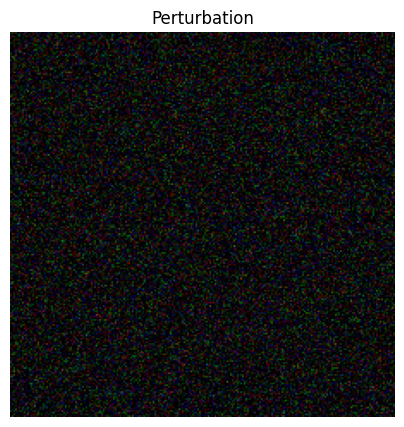

In [140]:
if len(top_perturbations) > 0:
    universal_perturbation = torch.mean(torch.stack(top_perturbations), dim=0)
    print(universal_perturbation.shape)
    print(f"Universal perturbation created.")
    visualize_perturbation(universal_perturbation)

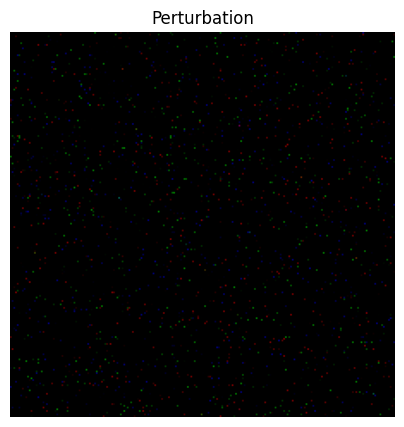

In [53]:
# Take the last one only (much smaller norm)
universal_perturbation = top_perturbations[-1]
visualize_perturbation(universal_perturbation)

# Metrics
(takes a while)

### GoogLeNet
(4 min)

In [155]:
evaluate_without_perturbation(model, dataloader, device)
# 0.6977

Using device: mps
Accuracy without perturbation: 0.69772


0.69772

In [54]:
evaluate_with_perturbation(model, dataloader, universal_perturbation, device)
# 9/24: 0.37964

# 12/24: 0.39556 (mean (higher norm)), 0.4017 (last one only)

Using device: mps
Accuracy with perturbation: 0.41226


0.41226

### ViT b 16

In [ ]:
evaluate_without_perturbation(model, dataloader, device)
# 0.811
# 13 mins

Using device: cpu


RuntimeError: Mismatched Tensor types in NNPack convolutionOutput

In [ ]:
evaluate_with_perturbation(model, dataloader, universal_perturbation, device)